### CSE 5243 - Introduction to Data Mining
## Homework 1: CRISP_DM Steps 2-3 (with Exploratory Data Analysis)
Replace the example information below with your real information:
- Semester: Spring 2026
- Instructor: Tom Bihari
- Section Wed/Fri 12:45PM
- Student Name: Nicholas McCracken
- Student Email: mccracken.161@osu.edu

Based on CRISP-DM Template Version V15.

***
### Use of Artificial Intelligence and Peer Collaboration in this Assignment
This course's syllabus incorporates standard syllabus statements maintained by the university.  See the statements regarding use of AI, Copyrights, etc., here:
- https://ugeducation.osu.edu/academics/standard-syllabus/standard-syllabus-statements
- https://ugeducation.osu.edu/academics/standard-syllabus/optional-syllabus-statements

Real-world development of analytics and engineering often requires significant collaboration and idea sharing. Collaborating with human peers and AI tools, including Generative AI, can be used to gather ideas, but assignment content and code must never be directly used from the peer or tool and then represented as your own original work. **The overall guidance follows the general Academic Integrity Policy: Your submission must be "your own original work" - not written by another person or AI.**

For this assignment:
- You may access online resources to view **examples** of the kinds of analyses you wish to perform in this asignment.
- You may search (or ask GenAI) for **examples** of short Python code snippets that show how to call a particular function, draw a particular kind of plot, etc.
- You **may not** ask GenAI to generate code specifically for this assignment, or for the given dataset.
- You **may not** copy/paste significant code snippets, etc., from online resources and claim it as your own.
- Similarly, your commentary, explanations, etc. in your assignment submission must be written by you alone, **not** assisted by GenAI or copied from another source.
- In all cases, you must comply with all **intellectual property** (e.g., copyright) requirements.

Given the rapid advances in GenAI, etc., it is difficult to provide a complete delineation of the specific boundaries of use. **If you have concerns or would like additional guidance, please reach out to me.**

In the following cell, **briefly describe** how you approached the use of the aforementioned resources (GenAI, etc.) for this assignment, and provide any thoughts or suggestions you have on the topic.  **This cell is not graded for specific content, but it must be filled in - the goal is to help us all build a general understanding of this landscape.**


I used an LLM for syntax questions. I found it especially helpful when generating plots and visuals, since matplotlib has a lot of complex syntax and it's functions have tons of possible attributes. GenAI helped make these visuals look more professional and standardized.

I also used the LLM for doing a basic comb-over of the data for missing information, which saved me time when I was exploring the dataset myself.

I think GenAI is a very useful tool for some of the more monotonous tasks. It was also helpful when creating the attribute table. I made sure to fill in my own notes and purposes for the attributes, but it was great at identifying data types. 

***
# Section: Overview
- Insert a short description of the scope of this exercise, any supporting information, etc.
- **(I will fill this in for each assignment - Tom Bihari)**
***

### Assignment Overview
In this assignment, you will analyze an ALTERED copy of the “Hotel Booking Cancelations dataset.
- This dataset was pulled on 1/19/26 from: https://www.kaggle.com/datasets/muhammaddawood42/hotel-booking-cancelations
- The dataset file is named: **hotel_cancellations_with_errors_V1.csv**

**The data has been altered slightly for use in course assignments,etc.:**
- A unique ROW attribute has been added.  Ignore the attribute when processing - it simply is an ID we can use if we want to discuss a specific data record.
- Errors have been added, such as: duplicated records, deleted records, deleted attribute values, erroneous attribute values.
**DO NOT PUBLISH THIS DATASET - it contains intentionally wrong data!**

This assignment covers the **first three of the six steps** of the **CRISP-DM process model** (Business Understanding, Data Understanding, Data Preparation). (See the CRISP-DM materials on CARMEN.)

The **objectives** of this assignment are:
- By analyzing and thinking critically about the data, you may identify interesting charcteristics that would be useful when using the data.
- The final, cleaned-up dataset that you create may be used to build classification / regression models in assignments.

### Problem Statement
Assume that you are the Director of Data Science for Buckeye Resorts, Inc. (BRI), an international hotel chain.

- As is the case for all hotel chains, reservation cancellations cause significant impacts to BRI, in profitability, logistics, and other areas.  The cost to BRI of a cancelled reservation is $500 on average. 

- BRI wants to improve (decrease) the cancellation rates at its hotels, using more tailored interventions, based on newly available detailed data.  BRI processes 100,000 reservations per year, so an incremental improvement in cancellation rates would have a significant impact.

- The current intervention is to charge a $100 cancellation fee for all cancelled reservations.  However, this still results in a net $400 loss ($500 - $100) for BRI for each cancellation, and causes negative customer impressions.  (For simplicity, assume this fee does not change the customers' likelihood of cancelling, and the given dataset reflects the "baseline" cancellation rate.)

- The specific "new" intervention is not yet known, but the assumption is that it would be based on predicting which reservations would be at risk of being cancelled and encouraging those customers to not cancel. If this new intervention is predicted to be better than the current intervention, then it would be adopted.

- BRI leadership has asked your team to analyze the new data, and determine if it is suitable for developing analyses and models that would be effective in predicting which future reservations are likely to be at risk of cancellation, so the new intervention could be offered.

You decide to look at the dataset, **explore (understand)** what it contains, and **create (prepare)** a clean dataset from it that contains the kind of information you think might be useful.

You do not yet know the specific algorithm, formula or model you will use to predict cancellations.  **That will come in a later step.**

### Things To Do
Complete the sections for the first three steps of CRISP-DM in this notebook.  Some intial guidance / sugggestions:
- **Business Understanding**: Fill in the cells, using your thoughts on the specific item.  Your answers will not be graded for "correctness", just "thoughtfulness".  Feel free to "invent" a narrative for detailed information not provided above.  Don't spend a lot of time on it.
- **Data Understanding**: There are many attributes in this dataset. Once you have done some initial analysis, you may choose to concentrate on ones that seem more promising or useful.  However, you must give evidence and explain why the attributes that you choose to give less attention warrant the lack of attention. 
- **Data Preparation**: Clean up the data and save it for future use.

It is essential that you **communicate** your goals, thought process, actions, results, and conclusions to the **audience** that will consume this work.  It is **not enough** to show just the code.  It is not appropriate to show long sections of **unexplained printout**, etc.  Be kind to your readers and provide value to them!

**ALWAYS follow this pattern** when doing **each portion** of the work.  This allows us to give feedback and assign scores, and to give partial credit.  Make it easy for the reader to understand your work.
- Say (briefly) **what** you are trying to do, and **why**.
- Do it (code).
- Show or describe the **result** clearly (and briefly as needed), and explain the significant **conclusions or insights** derived from the results. 

**HAVE FUN!**

***
# Section: Setup
- Add any needed imports, helper functions, etc., here.
***

In [462]:
import numpy as np
import pandas as pd

#!pip install matplotlib
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
#matplotlib.use('Qt5Agg')

import seaborn as sns

pd.set_option('display.max_columns', 50) #include to avoid ... in middle of display

***
# Section: 1 - Business Understanding - **SKIP THIS!**
This step is essential (and occasionally ignored…).  It focuses on understanding the business needs and objectives, and defining a data analysis problem that is relevant and useful to the business, so the right solution is built.  Consider the following questions and discuss the possible answers to them in the space below.  (You can just edit the existing cells if you like.)
- It is OK to say that you do not know.  How might you get answers to the questions?
- You may consider some of the questions to be "not applicable".  If so, why?
- You are encouraged to use markdown instead of raw text in the answer cells, to make them "pretty" and easy to read.
- This list of questions is not comprehensive.  Feel free to add other questions and comments.
***
**Context**
- What is the overview, history, big picture?

**Business Objectives**
- What is the problem or opportunity to be addressed / solved?
- What is its business value?

**Stakeholders**
- Who are they?
- What are their needs?

**General Goals**
- Understand the past/current state (descriptive)?
- Predict the future (predictive)?
- Mine for unknown patterns / insights?
- Answer questions? What are they?
- Support decisions? What are they?

**Scope**
- What is the specific scope of the project?
- What, specifically, is NOT in scope? (What are you not doing that someone might think you are doing?) Is the scope flexible? In what way?

**Deliverables**
- Report?
- Reusable code?
- Presentation?

**Success Criteria**
- What, specifically, must be accomplished for this project to be a success?

**Solution Approach**
- Is this a “one time” (throw away) solution?
- Or will the solution become part of repeated process that is used and enhanced over time?

**Quality**
- What level of Correctness or Confidence is needed?
- Is this life-critical or are we looking for ‘directionally correct’ results?

**Constraints**
- Are there legal / regulatory implications (privacy, security, liability, HIPAA, FERPA)?
- Are there architectural constraints?

**Time / Cost**
- What is the deadline or budget?

**Dependencies**
- Is this project dependent on any other project or activity?
- Is any other project or activity dependent on this project?

**Resources Needed**
- Do you potentially need access to specific people, data, etc?

**Other Considerations**
- What other considerations, not covered above, might be relevant?

***
# Section: 2 - Data Understanding - **DO THIS!**
- Perform exploratory data analysis of the dataset by looking at individual attributes and/or combinations of attributes. You should focus on identifying and describing interesting observations and insights that you might uncover from the data.
- You should not simply provide the basic EDA information for all attributes in the data. Instead, you should focus on those that are more interesting or important, and provide some discussion of what you observe. Pay particular attention to potentially interesting bivariate (two-variable) relationships, as well as the relationship between each attribute and the class attribute (if this is a classification problem).
- This step includes:
  - Understanding what data might be available and relevant.
  - Acquiring the data.
  - Understanding the characteristics of the data (e.g., quality, completeness, currency, consistency,…).
  - Understanding how other datasets might enhance or supplement the data (and acquiring that data as well).
  - Possibly performing some initial analysis to build confidence that the overall direction is likely to be helpful to the business problem to be solved.

**NOTE:** Frequently, a first pass is made through the data to fix or remove "obvious" data quality issues (missing values, duplicate records, outliers (some), etc.).  The deeper Data Understanding analysis then is done on the "cleaned" data.  This mitigates the issue of bad data skewing the data analysis results.  **You may choose to do this separate first pass. If you do so, clearly document your approach.**
***

***
## Section: 2.1 - Explore the Metadata and the Dataset.

Before using a dataset, it is important to gain an initial understanding of the dataset, to see if it meets our needs.  In particular, we need to:
- Identify important characteristics of the data (e.g., quality, completeness, currency, consistency,…).
  - Is this dataset relevant and appropriate for the goals of this project?
  - If not, what could you do? (find other data to replace or supplement this dataset, etc.)

To accomplish this:
- Find and examine the dataset's metadata.  Be careful!  Hand-written metadata is frequently out of date or incorrect.
- Load and briefly examine the charcteristics of the dataset.
***

**Examine the Metadata.**

Collect the information for each attribute.
  - Categorical: Nominal, Ordinal; Numerical: Interval, Ratio; Other: Complex or unstructured data (e.g., text strings, images,...)
  - This determines what operations are "meaningful" for each attribute.  For example, you can't add two Ordinal attributes.
  - You can't always tell the attribute types from the data itself.  For example, an Integer attribute could be Ordinal or Interval.

Create a table, such as:
| **Attribute** | **Type** | **DataType** | **UnitOfMeasure** | **Meaning** | **Notes** |
| --- | --- | --- | --- | --- | --- |
| ROW | Ordinal | Integer | No Unit - Just an index | Record number; not real data | This is handy for documentation purposes |
| etc. |

Note any concerns, considerations, or questions regarding this data.

Fill in...

### **Load and Examine the Dataset.**

In [463]:
# Note: Edit the path here to match your setup.  The "tiny" dataset contains just a few records to make it quick to test code.  The "with_errors" dataset is for the actual assignment.
data_df = pd.read_csv('./hotel_booking_V1/hotel_booking_tiny_V1.csv')
data_df = pd.read_csv('./hotel_booking_V1/hotel_booking_with_errors_V1.csv')

# Note: Do not use the ROW attribute as data, and do not include it in any analyses.  It's only purpose is to support referring to a row in the data for documentation purposes, if any.

In [464]:
data_df.head().T

,0,1,2,3,4
ROW,1,2,3,4,5
hotel,Resort Hotel,Resort Hotel,Resort Hotel,Resort Hotel,Resort Hotel
is_canceled,0,0,0,0,0
lead_time,342,737,7,13,14
arrival_date_year,2015,2015,2015,2015,2015
arrival_date_month,July,July,July,July,July
arrival_date_week_number,27,27,27,27,27
arrival_date_day_of_month,1,1,1,1,1
stays_in_weekend_nights,0,0,0,0,0
stays_in_week_nights,0,0,1,1,2


In [465]:
data_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 37 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ROW                             119390 non-null  int64  
 1   hotel                           119390 non-null  str    
 2   is_canceled                     119390 non-null  int64  
 3   lead_time                       119390 non-null  int64  
 4   arrival_date_year               119390 non-null  int64  
 5   arrival_date_month              119390 non-null  str    
 6   arrival_date_week_number        119390 non-null  int64  
 7   arrival_date_day_of_month       119390 non-null  int64  
 8   stays_in_weekend_nights         119390 non-null  int64  
 9   stays_in_week_nights            119390 non-null  int64  
 10  adults                          119390 non-null  int64  
 11  children                        119386 non-null  float64
 12  babies                     

In [466]:
metadata = [
    ("ROW", "Identifier", "Integer", "N/A",
     "Unique row identifier",
     "Record number; not real data"),

    ("hotel", "Categorical", "Nominal", "N/A",
     "Hotel type (city or resort)",
     ""),

    ("is_canceled", "Categorical", "Binary", "{0,1}",
     "1 if booking was canceled, else 0",
     "Class attribute to analyze"),

    ("lead_time", "Numerical", "Ratio", "days",
     "Days between booking and arrival",
     "Should be >= 0"),

    ("arrival_date_year", "Numerical", "Interval", "year",
     "Arrival year",
     ""),

    ("arrival_date_month", "Categorical", "Ordinal", "month",
     "Arrival month name",
     "Ordered Jan to Dec"),

    ("arrival_date_week_number", "Categorical", "Ordinal", "week number",
     "Week number of year",
     "Ordered 1 to 53"),

    ("arrival_date_day_of_month", "Categorical", "Ordinal", "day",
     "Day of month",
     ""),

    ("stays_in_weekend_nights", "Numerical", "Ratio", "nights",
     "Weekend nights booked",
     ""),

    ("stays_in_week_nights", "Numerical", "Ratio", "nights",
     "Weekday nights booked",
     ""),

    ("adults", "Numerical", "Ratio", "persons",
     "Number of adults",
     ""),

    ("children", "Numerical", "Ratio", "persons",
     "Number of children",
     ""),

    ("babies", "Numerical", "Ratio", "persons",
     "Number of babies",
     ""),

    ("meal", "Categorical", "Nominal", "N/A",
     "Meal plan selected",
     ""),

    ("country", "Categorical", "Nominal", "country code",
     "Country of origin",
     ""),

    ("market_segment", "Categorical", "Nominal", "N/A",
     "Market segment classification",
     ""),

    ("distribution_channel", "Categorical", "Nominal", "N/A",
     "Booking distribution channel",
     ""),

    ("is_repeated_guest", "Categorical", "Binary", "{0,1}",
     "1 if repeated guest, else 0",
     ""),

    ("previous_cancellations", "Numerical", "Ratio", "bookings",
     "Number of previous cancellations",
     ""),

    ("previous_bookings_not_canceled", "Numerical", "Ratio", "bookings",
     "Number of previous non-canceled bookings",
     ""),

    ("reserved_room_type", "Categorical", "Nominal", "code",
     "Reserved room type",
     ""),

    ("assigned_room_type", "Categorical", "Nominal", "code",
     "Assigned room type",
     "May differ from reserved"),

    ("booking_changes", "Numerical", "Ratio", "changes",
     "Number of booking changes",
     ""),

    ("deposit_type", "Categorical", "Nominal", "N/A",
     "Deposit type",
     "Indicates if a deposit was made"),

    ("agent", "Categorical", "Nominal", "ID",
     "Travel agent identifier",
     ""),

    ("company", "Categorical", "Nominal", "ID",
     "Company identifier",
     ""),

    ("days_in_waiting_list", "Numerical", "Ratio", "days",
     "Days on waiting list",
     ""),

    ("customer_type", "Categorical", "Nominal", "N/A",
     "Customer type",
     ""),

    ("adr", "Numerical", "Ratio", "currency per night",
     "Average Daily Rate",
     "Should be >= 0"),

    ("required_car_parking_spaces", "Numerical", "Ratio", "spaces",
     "Required parking spaces",
     ""),

    ("total_of_special_requests", "Numerical", "Ratio", "requests",
     "Number of special requests",
     ""),

    ("reservation_status", "Categorical", "Nominal", "N/A",
     "Reservation status label",
     ""),

    ("reservation_status_date", "Date-Time", "Date", "date",
     "Date of reservation status",
     ""),

    ("name", "Text", "String", "N/A",
     "Customer name",
     "Personally identify info; should be removed"),

    ("email", "Text", "String", "N/A",
     "Customer email",
     "Personally identify info; should be removed"),

    ("phone-number", "Text", "String", "N/A",
     "Customer phone number",
     "Personally identify info; should be removed"),

    ("credit_card", "Text", "String", "N/A",
     "Credit card number",
     "Personally identify info; should be removed"),
]

metadata_df = pd.DataFrame(metadata, columns=["Attribute", "Type", "DataType", "UnitOfMeasure", "Meaning", "Notes"])
metadata_df

,Attribute,Type,DataType,UnitOfMeasure,Meaning,Notes
0,ROW,Identifier,Integer,N/A,Unique row identifier,Record number; not real data
1,hotel,Categorical,Nominal,N/A,Hotel type (city or resort),
2,is_canceled,Categorical,Binary,"{0,1}","1 if booking was canceled, else 0",Class attribute to analyze
3,lead_time,Numerical,Ratio,days,Days between booking and arrival,Should be >= 0
4,arrival_date_year,Numerical,Interval,year,Arrival year,
5,arrival_date_month,Categorical,Ordinal,month,Arrival month name,Ordered Jan to Dec
6,arrival_date_week_number,Categorical,Ordinal,week number,Week number of year,Ordered 1 to 53
7,arrival_date_day_of_month,Categorical,Ordinal,day,Day of month,
8,stays_in_weekend_nights,Numerical,Ratio,nights,Weekend nights booked,
9,stays_in_week_nights,Numerical,Ratio,nights,Weekday nights booked,


**Discussion:**

From your examination of the metadata and the dataset, what is your conclusion about this dataset?  Does it appear (so far) to satisfy your needs?  Are there any concerns?

The dataset looks appropriate to perform a booking cancellation analysis on. We'll want to analyze the is_canceled class attribute based on supplementary attributes about the booking like lead time, booking changes, cancellation history, and if a deposit was made. These supplementary attributes should be more than enough to gleam some insight as to when cancellation is likely. There are concerns with data quality like missing values, and personally identifying data attributes that are not necessary for analysis and may cause ethical concerns if included.

***
## Section: 2.2 - Provide basic statistics for the attributes.
- For example: counts, percentiles, mean, median, standard deviation. The statistics should be relevant for the type of attribute.
***

In [467]:
data_df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ROW,119390.0,NaN,NaN,NaN,59695.500025,34465.0687,1.0,29848.25,59695.5,89542.75,119390.0
hotel,119390,3,City Hotel,79330,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_canceled,119390.0,NaN,NaN,NaN,0.370416,0.482918,0.0,0.0,0.0,1.0,1.0
lead_time,119390.0,NaN,NaN,NaN,104.003736,106.871811,-510.0,18.0,69.0,160.0,737.0
arrival_date_year,119390.0,NaN,NaN,NaN,2016.156554,0.707476,2015.0,2016.0,2016.0,2017.0,2017.0
arrival_date_month,119390,12,August,13877,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrival_date_week_number,119390.0,NaN,NaN,NaN,27.165173,13.605138,1.0,16.0,28.0,38.0,53.0
arrival_date_day_of_month,119390.0,NaN,NaN,NaN,15.798224,8.780802,1.0,8.0,16.0,23.0,31.0
stays_in_weekend_nights,119390.0,NaN,NaN,NaN,0.927599,0.998613,0.0,0.0,1.0,2.0,19.0
stays_in_week_nights,119390.0,NaN,NaN,NaN,2.500318,1.908316,0.0,1.0,2.0,3.0,50.0


**Discussion:**

Some attributes have missing values (agent, company) as indicated by their count, which is fewer than the other attributes count of 119390, which means they'll require special treatment if they are too be included in the analysis. There's an abnormally high max and standard deviation for the adr and lead_time attributes, telling us that outliers are prominent in these data fields. These outliers could be filtered out for a more generalized analysis of cancellation likelihood. Additionally, the mean of the binary attribute is_canceled gives us the cancellation rate of bookings in the dataset.

***
## Section: 2.3 - Visualize / analyze the most important or interesting attributes using appropriate techniques.
- For each visualization, provide an interpretation explaining why it is appropriate or interesting. What does each visualization tell us?
***

Overall cancellation rate: 0.370


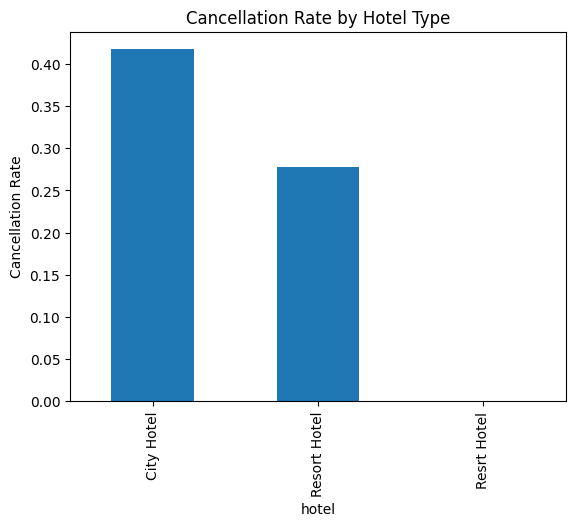

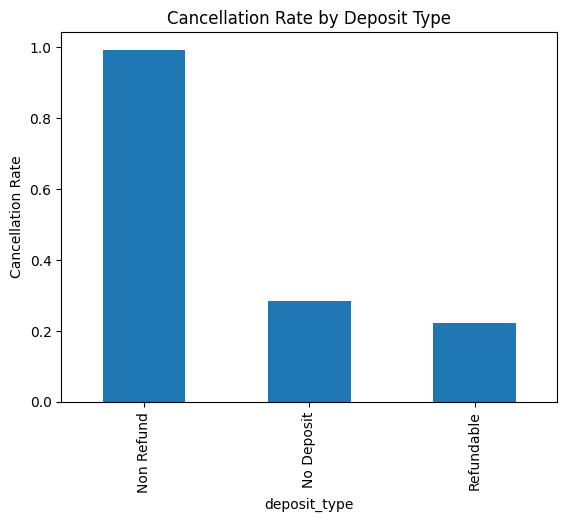

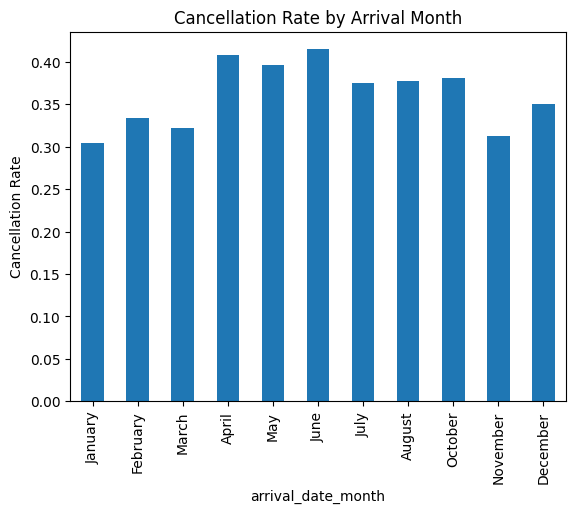

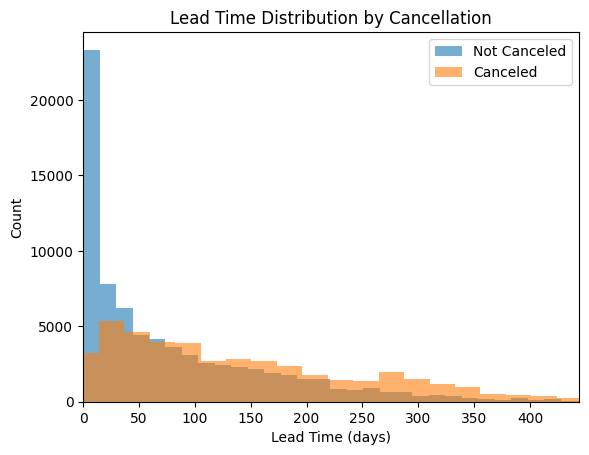

In [468]:
# Overall cancellation rate
cancellation_rate = data_df["is_canceled"].mean()
print(f"Overall cancellation rate: {cancellation_rate:.3f}")

# Cancellation rate by hotel type
cancellation_by_hotel = data_df.groupby("hotel")["is_canceled"].mean().sort_values(ascending=False)
cancellation_by_hotel.plot(kind="bar")
plt.ylabel("Cancellation Rate")
plt.title("Cancellation Rate by Hotel Type")
plt.show()

# Cancellation rate by deposit type
cancellation_by_deposit = data_df.groupby("deposit_type")["is_canceled"].mean().sort_values(ascending=False)
cancellation_by_deposit.plot(kind="bar")
plt.ylabel("Cancellation Rate")
plt.title("Cancellation Rate by Deposit Type")
plt.show()

# Cancellation rate by arrival month
cancellation_by_month = data_df.groupby("arrival_date_month")["is_canceled"].mean()
month_order = ["January", "February", "March", "April", "May", "June", "July", "August"," September", "October", "November", "December"]
cancellation_by_month = cancellation_by_month.reindex([month for month in month_order if month in cancellation_by_month.index])
cancellation_by_month.plot(kind="bar")
plt.ylabel("Cancellation Rate")
plt.title("Cancellation Rate by Arrival Month")
plt.show()

# Distribution of lead time by cancellation status
lead_time_not_cancelled = data_df.loc[data_df["is_canceled"] == 0, "lead_time"].dropna()
lead_time_cancelled = data_df.loc[data_df["is_canceled"] == 1, "lead_time"].dropna()

plt.hist(lead_time_not_cancelled, bins=50, alpha=0.6, label="Not Canceled")
plt.hist(lead_time_cancelled, bins=50, alpha=0.6, label="Canceled")
plt.xlim(0, np.percentile(data_df["lead_time"].dropna(), 99))  # meant to help with skewing on the right side of the histogram due to extreme outliers
plt.xlabel("Lead Time (days)")
plt.ylabel("Count")
plt.title("Lead Time Distribution by Cancellation")
plt.legend()
plt.show()


**Discussion:**

The first visual tells us the City Hotel cancellation rate is over 10% higher than the Resort Hotel cancellation rate. These categories are very high level, and by diving deeper we could identify what is causing this discrepancy in cancellation rates based on other related attributes. There's also an identifiable typo class of "Resrt Hotel" which can be dropped in the data cleaning step.

The second indicates that non-refundable deposits actually have higher cancellation rates, which seems counter intuitive. By offering more refundable deposits, cancellation rates could potentially be lowered based off this figure.

The third visual shows us how seasonality affects cancellation rates. Common vacactioning months (April, May, June) at the start of summer have the highest cancellation rates. More favorable terms could be offered during these time periods to avoid reduce cancellations.

Finally, the last visual provides a histogram that shows the relationship between lead time and cancellation. Very low lead times tend to have very low cancellations. The most common period of cancellation is within a month but not a week of the booking, based on this chart.

***
## Section: 2.4 - Verify data quality: explain any missing values, duplicate data, or outliers.
- What, if anything, do you need to do about these? Be specific.
***

### Missing Attribute Values

In [469]:
# Calculate missing value counts and rates for each column
missing_counts = data_df.isna().sum().sort_values(ascending=False)
missing_rates = (missing_counts / len(data_df)).round(4)

missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_rate": missing_rates
})
    
missing_summary.head(10)


,missing_count,missing_rate
company,112593,0.9431
agent,16340,0.1369
country,488,0.0041
children,4,0.0000
phone-number,1,0.0000
meal,1,0.0000
ROW,0,0.0000
booking_changes,0,0.0000
deposit_type,0,0.0000
days_in_waiting_list,0,0.0000


**Discussion:**

- A default value could be added for the missing **company** and **agent** values. It's likely that these bookings were made by people not associated with a company or agent, but no proper default value is implemented.
- The missing **country** values could be given a default as well. These could be bookings made from non-self-governing territories. 
- The missing **children** values could be filled with 0.
- The missing **phone-number** and **meal** only accounts for two rows, which could be dropped without issue for the purpose of this analysis.

### Duplicate Records

In [470]:
# Duplicate across row check
duplicate_rows = data_df[data_df.duplicated()]
print(f"Number of duplicate rows: {duplicate_rows.shape[0]}")
duplicate_rows.head(10)


Number of duplicate rows: 1


,ROW,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
119389,119390,City Hotel,0,205,2017,August,35,29,2,7,2,0.0,0,HB,DEU,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9.0,NaN,0,Transient,151.2,0,2,Check-Out,9/7/2017,Ariana Michael,Ariana_M@xfinity.com,422-804-6403,************4482


**Discussion:**

The rows 119389 and 119390 are identical. One of the rows could be dropped.


In [471]:
# Duplicate ROW ids
duplicate_rows = data_df[data_df.duplicated(['ROW',])]
list_of_duplicates = duplicate_rows['ROW'].unique()
list_of_duplicates.sort()
complete_duplicate_rows = data_df[data_df['ROW'].isin(list_of_duplicates)]

print(f"Number of duplicate rows: {duplicate_rows.shape[0]}")
complete_duplicate_rows.head(10)

Number of duplicate rows: 1


,ROW,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
119388,119390,City Hotel,0,205,2017,August,35,29,2,7,2,0.0,0,HB,DEU,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9.0,NaN,0,Transient,151.2,0,2,Check-Out,9/7/2017,Ariana Michael,Ariana_M@xfinity.com,422-804-6403,************4482
119389,119390,City Hotel,0,205,2017,August,35,29,2,7,2,0.0,0,HB,DEU,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9.0,NaN,0,Transient,151.2,0,2,Check-Out,9/7/2017,Ariana Michael,Ariana_M@xfinity.com,422-804-6403,************4482


**Discussion:**

There's no new identical rows that weren't discovered in the previous step, so no action is needed.


### Outliers

In [472]:
outliers = {}

# Check if ADR is negative or too large
outliers["adr_negative"] = int((data_df["adr"] < 0).sum())
outliers["adr_too_large"] = int((data_df["adr"] > 300).sum())

# Check if adults/children/babies total to zero guests
total_guests = data_df[["adults","children","babies"]].fillna(0).sum(axis=1)
outliers["zero_total_guests"] = int((total_guests == 0).sum())

# Check if lead time is too negative or too large
outliers["lead_time_negative"] = int((data_df["lead_time"] < 0).sum())
outliers["lead_time_too_large"] = int((data_df["lead_time"] > 500).sum())

# Check if day of month outside range 1 to 31
outliers["arrival_day_outside_1_31"] = int(((data_df["arrival_date_day_of_month"] < 1) | (data_df["arrival_date_day_of_month"] > 31)).sum())

pd.Series(outliers)


adr_negative                  1
adr_too_large               276
zero_total_guests           180
lead_time_negative            1
lead_time_too_large         480
arrival_day_outside_1_31      0
dtype: int64

**Discussion:**

- A couple basic thresholds were chosen to indicate what qualifies as an outlier which is too large for both **lead time** and **ADR**, which are important indicators to cancellation likelihood.
- A more robust filter could be iterate upon this idea by generating a threshold programatically based on the data. 
- Some more basic checks include ensuring that there is a non-zero number of guests, and there are no negatives in important rows. These rows can be dropped safely to improve data quality.

***
## Section: 2.5 - Explore the relationships among the attributes.
- You may include or exclude the class attribute as appropriate.
- Use scatter plots, correlation matrices, cross-tabulations, group-wise averages, or other appropriate techniques. Explain and interpret any interesting relationships.
- There are three general cases for 2-attribute relationships:
  - Categorical vs Categorical
  - Categorical vs Numerical
  - Numerical vs Numerical
- See these references for additional guidance:
  - https://www.scribbr.com/statistics/statistical-tests/
  - https://researcher.life/blog/article/independent-vs-dependent-variables-definition-examples/
  - https://medium.com/@outside2SDs/an-overview-of-correlation-measures-between-categorical-and-continuous-variables-4c7f85610365
***

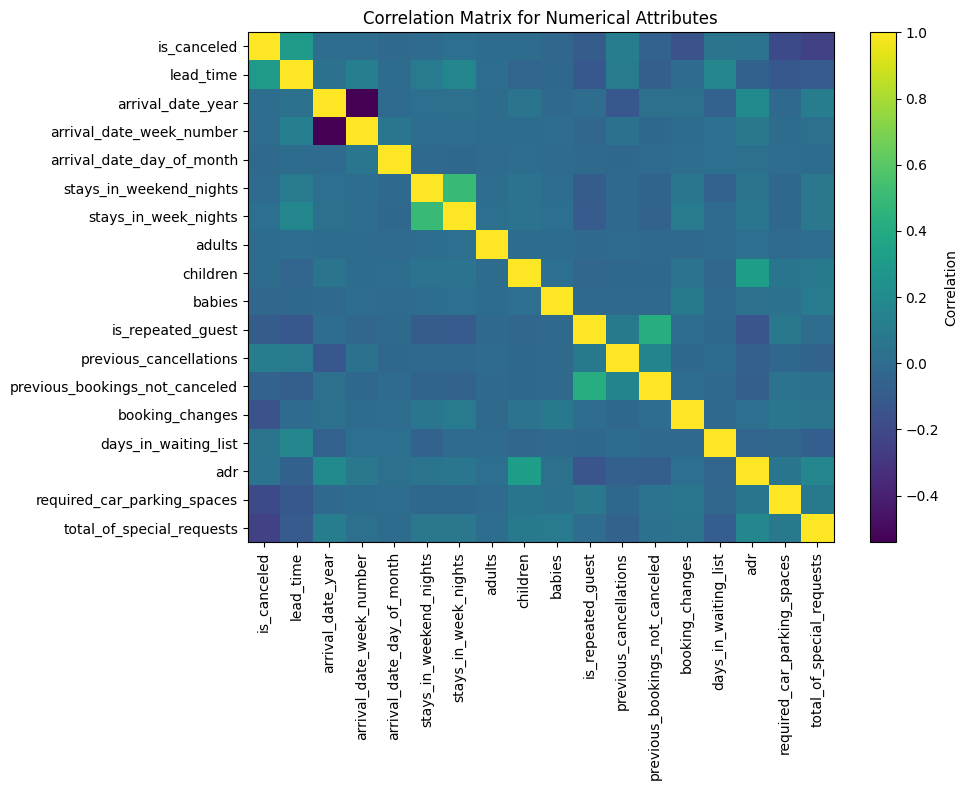

In [473]:
# Correlation matrix for numeric attritbutes 

numerical_columns = data_df.select_dtypes(include=[np.number]).columns.tolist()

# Remove fields that just represent IDs and not numerical data
id_fields = [column for column in ["ROW", "agent", "company"] if column in numerical_columns]
use_columns = [column for column in numerical_columns if column not in id_fields]

# Generate correlation matrix
correlation_matrix = data_df[use_columns].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(use_columns)), use_columns, rotation=90)
plt.yticks(range(len(use_columns)), use_columns)
plt.title("Correlation Matrix for Numerical Attributes")
plt.tight_layout()
plt.show()


**Discussion:**

- Strong correlation between stay length attributes of **stay_in_weekend_nights** and **stay_in_week_nights** because they are essentially attempting to capture the same measurement. This is similiar logically for **is_repeated_guests** and **previous_bookings_not_canceled**.
- Most attributes have weak correlation with the class attribute **is_canceled**. This implies that cancellations are influenced by a lot of different combined attributes rather than one single attribute driving the majority of cancellations, hence the necessity for this detailed analysis of the booking dataset.

***
## Section: 2.6 - Identify and explain any interesting relationships between the class attribute and the other attributes.
- You may refer to earlier analyses / visualizations (if you included the class attribute above) or create new ones.
***

**Discussion:**

The cancellation rate class attribute is most strongly affected by several class attributes. For example, deposit type has a very strong relationship with the class attribute. Bookings with a non-refundable deposit are almost guarenteed to be cancelled. This could be for a few reasons depending on the business. A valid hypothesis might be that non-refundable deposits are only required for customers who have a high cancellation rate already, for example. There is a noticeable decrease in cancellations when some deposit is required compared to none though. Market segment, customer type, hotel type, and seasonal month also have sway over the likelihood of cancellation.

The lead_time numerical attribute is the most closely related to whether a booking is cancelled of any numerical attribute. The longer lead time, the more likely cancellation is to occur. This is likely because when bookings are made far in advance, there's more room for customers to change their plans. 

Both of these classification and numerical attributes should be considered when analyzing why a cancellation occured.

***
# Section: 3 - Data Preparation - **DO THIS!**
In this step, the “final” target dataset is constructed (although nothing is ever final…), based on the insights gleaned in the Data Understanding step.
This may include:
- Normalizing / standardizing the data.
- Handling missing and erroneous data.
- Transforming or eliminating attributes.
- “Blending” data from multiple sources (with attention to consistency of the various sources).
- Deploying the data to storage in suitable formats, data models / structures.

**NOTE:** In each of these sections, it is OK to decide to **not** make changes to the dataset, but you **must** explain **why** you made the choice.  Recall that the purpose of this step is to produce a clean dataset that is suitable for the intended purposes.  So, for example, you might choose to not remove any attributes, but if you have 100 apparently irrelevant attributes, explain why are you keeping them - there may be a good reason.
***

***
## Section: 3.1 - Clean the Data
- Implement any data cleaning steps previously identified.  Please justify.
- Show the effects of that cleaning through the use of appropriate statistics and/or visualizations.
***

In [474]:
clean_df = data_df.copy()

# Parse data
clean_df["reservation_status_date"] = pd.to_datetime(clean_df["reservation_status_date"], errors="coerce")

# Fix resort hotel typo
clean_df["hotel"] = clean_df["hotel"].replace(to_replace='Resrt Hotel', value='Resort Hotel')

# Fill missing children values
clean_df["children"] = clean_df["children"].fillna(0) 

# Use bounds to remove outlier rows
valid_rows = (
    (clean_df["adr"] >= 0) &
    (clean_df["adr"] <= 300) &
    (clean_df["lead_time"] >= 0) &
    (clean_df["lead_time"] <= 500) &
    (clean_df["arrival_date_day_of_month"] >= 1) &
    (clean_df["arrival_date_day_of_month"] <= 31)
)

clean_df = clean_df[valid_rows].copy()

# Add explicit default value of N/A to attributes with lots of missing values
for column in ["country", "agent", "company"]:
    if column not in clean_df.columns: continue
    
    clean_df[column] = clean_df[column].astype("string")
    clean_df[column] = clean_df[column].fillna("N/A")

# Show how many rows were removed via cleaning
print("Original rows:", data_df.shape[0])
print("Cleaned rows:", clean_df.shape[0])
print("Rows removed:", data_df.shape[0] - clean_df.shape[0])

Original rows: 119390
Cleaned rows: 118632
Rows removed: 758


**Discussion:**

- The Resrt Hotel typo was updated to Resort Hotel to match the other columns. 
- Missing values were filled with the defaults suggested in Section 2.
- Boundaries for outliers were implemented using a row validation list. This ensures no negatives or large outliers are present to skew the data.

***
## Section: 3.2 - Select Attributes
- Optionally, remove attributes that are unneeded, redundant, etc., for the expected uses.
- Which attributes did you decide to remove, if any? Please justify.
***

In [475]:
# Remove personally identifiable information columns
personal_columns = ["name", "email", "phone-number", "credit_card"]
clean_df = clean_df.drop(columns=personal_columns, errors="ignore")

clean_df.head(10)

,ROW,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,1,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,N/A,N/A,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,3,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,N/A,N/A,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,4,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,N/A,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,5,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,N/A,0,Transient,98.0,0,1,Check-Out,2015-07-03
5,6,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,N/A,0,Transient,98.0,0,1,Check-Out,2015-07-03
6,7,Resort Hotel,0,0,2015,July,27,1,0,2,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,0,No Deposit,N/A,N/A,0,Transient,107.0,0,0,Check-Out,2015-07-03
7,8,Resort Hotel,0,9,2015,July,27,1,0,2,2,0.0,0,FB,PRT,Direct,Direct,0,0,0,C,C,0,No Deposit,303.0,N/A,0,Transient,103.0,0,1,Check-Out,2015-07-03
8,9,Resort Hotel,1,85,2015,July,27,1,0,3,2,0.0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,N/A,0,Transient,82.0,0,1,Canceled,2015-05-06
9,10,Resort Hotel,1,75,2015,July,27,1,0,3,2,0.0,0,HB,PRT,Offline TA/TO,TA/TO,0,0,0,D,D,0,No Deposit,15.0,N/A,0,Transient,105.5,0,0,Canceled,2015-04-22
10,11,Resort Hotel,1,23,2015,July,27,1,0,4,2,0.0,0,BB,PRT,Online TA,TA/TO,0,0,0,E,E,0,No Deposit,240.0,N/A,0,Transient,123.0,0,0,Canceled,2015-06-23


**Discussion:**

- For ethical safety reasons, personally identifying info was removed as it is not necessary for the goal of this analysis.

***
## Section: 3.3 - Create Attributes
- Optionally, create new attributes based on the values of other attibutes.
- Which new attributes did you decide to create, if any? Please justify.
***

In [476]:
# Create guests total
clean_df["total_guests"] = clean_df[["adults", "children", "babies"]].fillna(0).sum(axis=1).astype(int)
clean_df = clean_df[clean_df["total_guests"] > 0].copy()

# Total nights stayed
clean_df["total_nights"] = clean_df["stays_in_weekend_nights"].fillna(0) + clean_df["stays_in_week_nights"].fillna(0)

# Create single arrival date attribute
month_to_num = {
    "January": 1, "February": 2, "March": 3, "April": 4, "May": 5, "June": 6,
    "July": 7, "August": 8, "September": 9, "October": 10, "November": 11, "December": 12
}

clean_df["arrival_month_num"] = clean_df["arrival_date_month"].map(month_to_num)

clean_df["arrival_date"] = pd.to_datetime(
    dict(year=clean_df["arrival_date_year"],
         month=clean_df["arrival_month_num"],
         day=clean_df["arrival_date_day_of_month"]),
    errors="coerce"
)

clean_df[["total_guests", "total_nights", "arrival_date"]].head(10)


,total_guests,total_nights,arrival_date
0,2,0,2015-07-01
2,1,1,2015-07-01
3,1,1,2015-07-01
4,2,2,2015-07-01
5,2,2,2015-07-01
6,2,2,2015-07-01
7,2,2,2015-07-01
8,2,3,2015-07-01
9,2,3,2015-07-01
10,2,4,2015-07-01


**Discussion:**

- A total guests attribute was created to sum the adults, children, and babies attributes. This allows for easy removal of zero guest bookings, which are invalid and unhelpful to the analysis.
- A total nights stayed attribute was created by summing the weekend nights and week nights attributes.
- The arrival year, month, and day attributes were combined into a single date attribute.
- Each of these new attributes makes the data more readable and analysis-friendly.

***
## Section: 3.4 - Transform Attributes
- Optionally, transform existing attributes (e.g., standardize, normalize, change units of measure, encode) to make them more appropriate for the expected uses.
- Which attributes did you decide to transform, if any? Please justify.
***

In [ ]:
# Update ID columns to be categorical strings
for column in ["agent", "company"]:
    if column in clean_df.columns:
        clean_df[column] = clean_df[column].astype("string")
        
clean_df.head(10)


,ROW,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_guests,total_nights,arrival_month_num,arrival_date
0,1,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,N/A,N/A,0,Transient,0.0,0,0,Check-Out,2015-07-01,2,0,7,2015-07-01
2,3,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,N/A,N/A,0,Transient,75.0,0,0,Check-Out,2015-07-02,1,1,7,2015-07-01
3,4,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,N/A,0,Transient,75.0,0,0,Check-Out,2015-07-02,1,1,7,2015-07-01
4,5,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,N/A,0,Transient,98.0,0,1,Check-Out,2015-07-03,2,2,7,2015-07-01
5,6,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,N/A,0,Transient,98.0,0,1,Check-Out,2015-07-03,2,2,7,2015-07-01
6,7,Resort Hotel,0,0,2015,July,27,1,0,2,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,0,No Deposit,N/A,N/A,0,Transient,107.0,0,0,Check-Out,2015-07-03,2,2,7,2015-07-01
7,8,Resort Hotel,0,9,2015,July,27,1,0,2,2,0.0,0,FB,PRT,Direct,Direct,0,0,0,C,C,0,No Deposit,303.0,N/A,0,Transient,103.0,0,1,Check-Out,2015-07-03,2,2,7,2015-07-01
8,9,Resort Hotel,1,85,2015,July,27,1,0,3,2,0.0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,N/A,0,Transient,82.0,0,1,Canceled,2015-05-06,2,3,7,2015-07-01
9,10,Resort Hotel,1,75,2015,July,27,1,0,3,2,0.0,0,HB,PRT,Offline TA/TO,TA/TO,0,0,0,D,D,0,No Deposit,15.0,N/A,0,Transient,105.5,0,0,Canceled,2015-04-22,2,3,7,2015-07-01
10,11,Resort Hotel,1,23,2015,July,27,1,0,4,2,0.0,0,BB,PRT,Online TA,TA/TO,0,0,0,E,E,0,No Deposit,240.0,N/A,0,Transient,123.0,0,0,Canceled,2015-06-23,2,4,7,2015-07-01


**Discussion:**

- Updated the agent and ccompany attributes to be treated like categorical strings rather than numerical data, since they function as ID values in the dataset.
- I didn't think any normalization steps were necessary seeing as outliers were removed in the data cleaning section 3.1.

***
## Section: 3.5 - Select Records
- Optionally, select a subset of the records, via sampling, etc., to decrease the size of the dataset. Please justify.
***

In [478]:
clean_df = clean_df.sample(n=30, replace=True, random_state=0)
clean_df.describe()

,ROW,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date,total_guests,total_nights,arrival_month_num,arrival_date
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.0,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.0,30.000000,30,30.000000,30.000000,30.000000,30
mean,67911.400000,0.266667,100.566667,2016.033333,29.166667,14.866667,0.800000,1.766667,1.833333,0.033333,0.0,0.033333,0.033333,0.133333,0.266667,1.466667,100.211667,0.0,0.566667,2016-07-18 20:48:00,1.866667,2.566667,7.033333,2016-07-28 12:48:00
min,6931.000000,0.000000,0.000000,2015.000000,4.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,34.000000,0.0,0.000000,2015-08-20 00:00:00,1.000000,1.000000,1.000000,2015-09-04 00:00:00
25%,42426.750000,0.000000,37.000000,2015.250000,18.750000,5.250000,0.000000,1.000000,2.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,73.747500,0.0,0.000000,2015-12-19 12:00:00,2.000000,2.000000,4.250000,2015-12-28 06:00:00
50%,74946.500000,0.000000,76.500000,2016.000000,31.500000,13.000000,0.500000,2.000000,2.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,95.450000,0.0,0.000000,2016-05-18 12:00:00,2.000000,2.000000,8.000000,2016-06-28 00:00:00
75%,95986.500000,0.750000,128.000000,2017.000000,38.500000,24.000000,2.000000,2.000000,2.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,120.000000,0.0,1.000000,2017-02-02 12:00:00,2.000000,3.000000,9.000000,2017-02-01 06:00:00
max,118869.000000,1.000000,457.000000,2017.000000,52.000000,28.000000,2.000000,4.000000,3.000000,1.000000,0.0,1.000000,1.000000,4.000000,2.000000,44.000000,204.900000,0.0,3.000000,2017-08-28 00:00:00,3.000000,6.000000,12.000000,2017-08-27 00:00:00
std,33386.701927,0.449776,101.376622,0.764890,14.078801,9.182943,0.886683,0.971431,0.461133,0.182574,0.0,0.182574,0.182574,0.730297,0.583292,8.033264,39.793263,0.0,0.817200,NaN,0.507416,1.278019,3.221515,NaN


**Discussion:**

There's no reason for trimming the dataset. The above code could be used for creating a very small sample dataset.

***
## Section: 3.6 - Other Data Preparation
- Optionally, perform other preparation steps (e.g., to optimize storage, retrieval, etc.). Please justify.
***

**Discussion:**

I did not see a need to perform any other data preparation steps.

***
# Section: 4 - Modeling - **SKIP THIS!**
In this step, the dataset is analyzed and used to create models and/or answer questions relevant to the business. This may include:
- Developing statistical models for describing or predicting business situations.
- Training data mining (e.g., machine learning) algorithms for classification, clustering, association analysis, outlier detection, and other uses.

NOTE: This step is tightly coupled and iterative with the Data Preparation and Evaluation steps.
***

**Discussion:**

Fill in...

***
# Section: 5 - Evaluation - **SKIP THIS!**
In this step, the analyses and/or models are evaluated for quality and relevance / usefulness.

NOTE: This step is tightly coupled and iterative with the Modeling step.
***

**Discussion:**

Fill in...

***
# Section: 6 - Deployment - **SKIP THIS!**
In this step, data and resulting models and/or analyses are put to use. This may include:
- Deploying data mining / machine learning algorithms to production.
- Communicating the results of the analyses to business stakeholders, so they can take action.
***

**Discussion:**

Fill in...

***
# Section: Conclusions - **DO THIS!**
- What did you learn from this exercise?
***

**Discussion:**

Fill in...